# **8. Evaluación**

In [1]:
import joblib
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, accuracy_score,
    roc_curve, confusion_matrix, classification_report
)

# Cargar tus datos de prueba
# (deben ser los originales, sin balanceo)
X_train = pd.read_csv("X_train_resampled.csv")
y_train = pd.read_csv("y_train_resampled.csv")['diabetes']
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")['diabetes']

In [2]:
def evaluar_modelo(nombre_modelo, ruta_pkl, X_test, y_test, X_train, y_train):
    
    modelo = joblib.load(ruta_pkl)
    
    start_time = time.time()
    modelo.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    train_score = modelo.score(X_train, y_train)
    test_score = modelo.score(X_test, y_test)
    
    # Predicciones
    y_pred = modelo.predict(X_test)
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
    except:
        # Algunos modelos no tienen predict_proba (como LinearSVC)
        y_proba = None
    
    # Métricas
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n🔹 Modelo: {nombre_modelo}")
    print(f"AUC: {auc:.3f} | F1: {f1:.3f} | Recall: {recall:.3f} | Accuracy: {acc:.3f} | Train Score: {train_score} | Test Score: {test_score} | Train Time: {train_time:.2f} s")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {nombre_modelo}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()
    
    # Curva ROC
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.title(f"Curva ROC - {nombre_modelo}")
        plt.xlabel("Tasa de falsos positivos")
        plt.ylabel("Tasa de verdaderos positivos")
        plt.legend()
        plt.show()
    
    return {'Modelo': nombre_modelo, 'AUC': auc, 'F1': f1, 'Recall': recall, 'Accuracy': acc,'Train Score':train_score, 'Test Score': test_score, 'Train Time (s)': train_time}


## **Modelo de `Regresión Logística L1 y L2`**

In [3]:
resultados_finales = []


🔹 Modelo: Regresión Logística
AUC: 0.788 | F1: 0.409 | Recall: 0.708 | Accuracy: 0.719 | Train Score: 0.7801078490113841 | Test Score: 0.7185111918053222 | Train Time: 6.29 s

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     63661
           1       0.29      0.71      0.41     10143

    accuracy                           0.72     73804
   macro avg       0.61      0.71      0.61     73804
weighted avg       0.85      0.72      0.76     73804



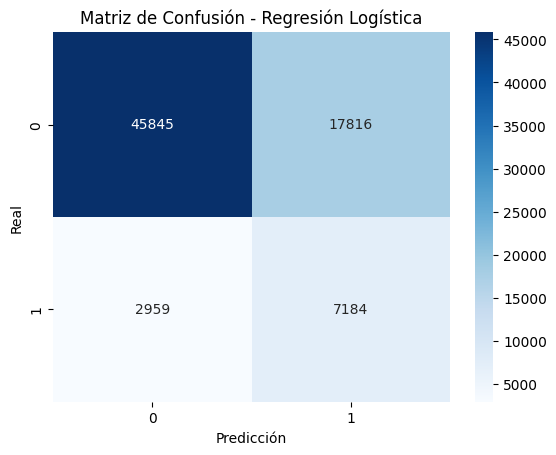

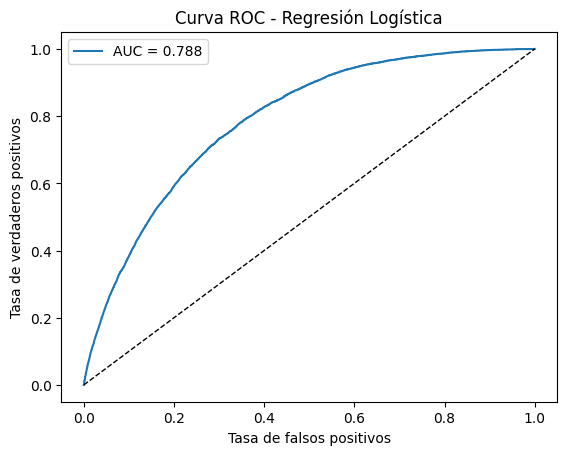

In [4]:
resultados_finales.append(evaluar_modelo("Regresión Logística", "modelo_logistica.pkl", X_test, y_test, X_train, y_train))

## **Modelo de ``KNN_NeighborsClassifier``**


🔹 Modelo: KNN
AUC: 0.748 | F1: 0.374 | Recall: 0.697 | Accuracy: 0.680 | Train Score: 0.9996903211907824 | Test Score: 0.6799089480244973 | Train Time: 1.69 s

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.68      0.78     63661
           1       0.26      0.70      0.37     10143

    accuracy                           0.68     73804
   macro avg       0.59      0.69      0.58     73804
weighted avg       0.84      0.68      0.73     73804



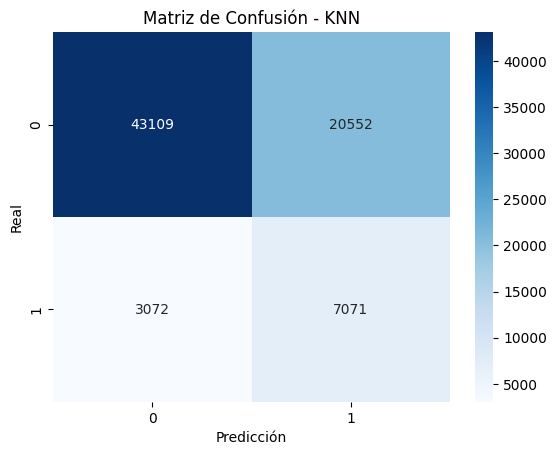

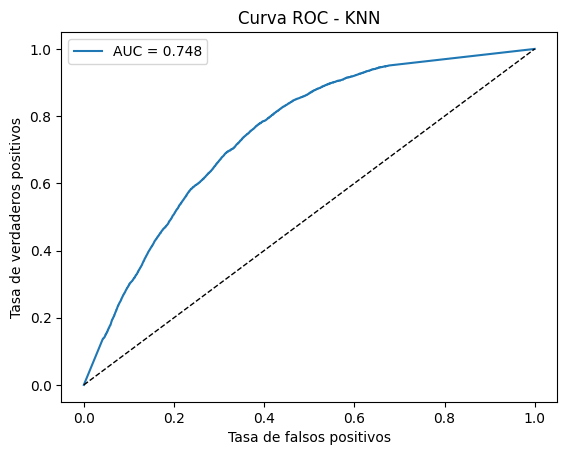

In [5]:
resultados_finales.append(evaluar_modelo("KNN", "modelo_knn.pkl", X_test, y_test, X_train, y_train))

## **Modelo de ``Naive Bayes``**


🔹 Modelo: Naive Bayes
AUC: 0.739 | F1: 0.315 | Recall: 0.834 | Accuracy: 0.502 | Train Score: 0.6922297547478474 | Test Score: 0.5020595089697035 | Train Time: 1.80 s

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.45      0.61     63661
           1       0.19      0.83      0.32     10143

    accuracy                           0.50     73804
   macro avg       0.57      0.64      0.46     73804
weighted avg       0.84      0.50      0.57     73804



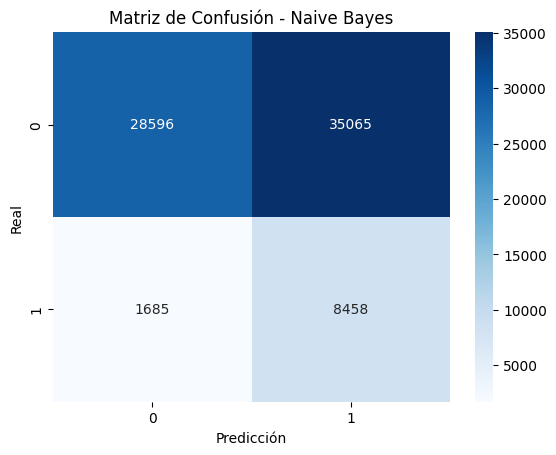

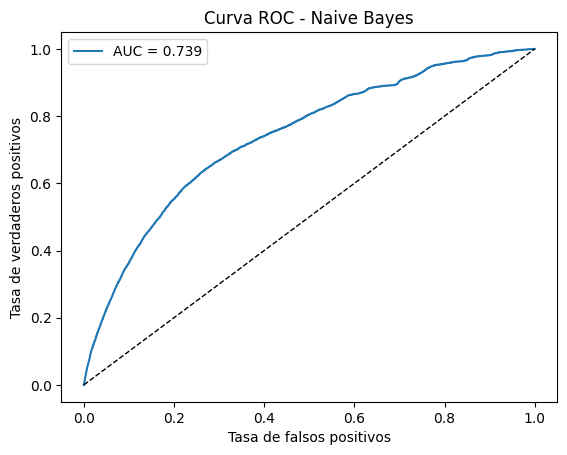

In [6]:
resultados_finales.append(evaluar_modelo("Naive Bayes", "modelo_nb.pkl", X_test, y_test, X_train, y_train))

## **Modelo de ``DecisionTreeClassifier``**


🔹 Modelo: Árbol de Decisión
AUC: 0.751 | F1: 0.377 | Recall: 0.630 | Accuracy: 0.713 | Train Score: 0.7793269198403134 | Test Score: 0.7134166169855293 | Train Time: 4.29 s

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.81     63661
           1       0.27      0.63      0.38     10143

    accuracy                           0.71     73804
   macro avg       0.60      0.68      0.60     73804
weighted avg       0.83      0.71      0.75     73804



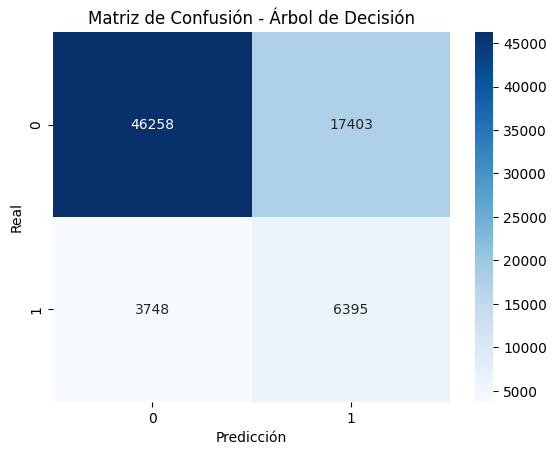

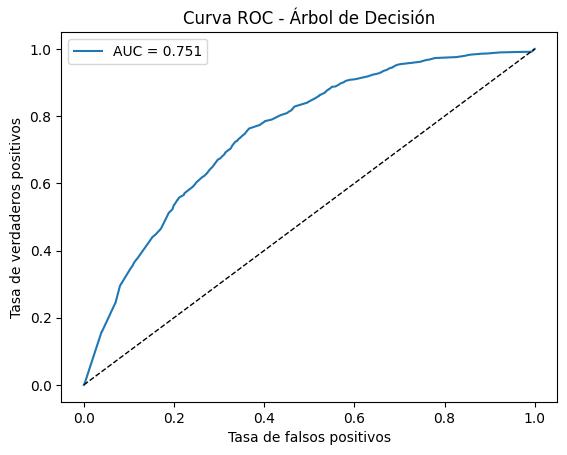

In [7]:
resultados_finales.append(evaluar_modelo("Árbol de Decisión", "modelo_tree.pkl", X_test, y_test, X_train, y_train))

## **Modelo de ``RandomForestClassifier``**


🔹 Modelo: Random Forest
AUC: 0.794 | F1: 0.380 | Recall: 0.381 | Accuracy: 0.829 | Train Score: 0.9996903211907824 | Test Score: 0.8292910953335862 | Train Time: 165.26 s

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     63661
           1       0.38      0.38      0.38     10143

    accuracy                           0.83     73804
   macro avg       0.64      0.64      0.64     73804
weighted avg       0.83      0.83      0.83     73804



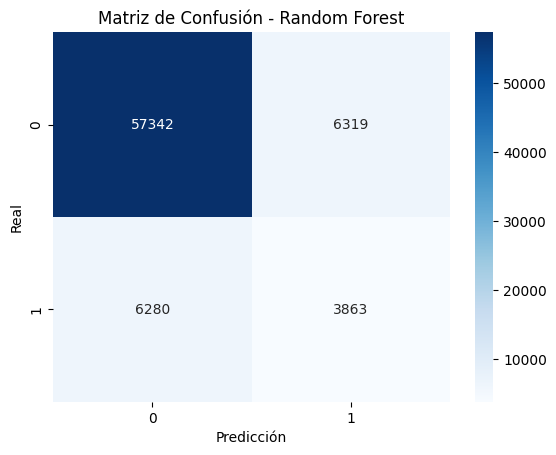

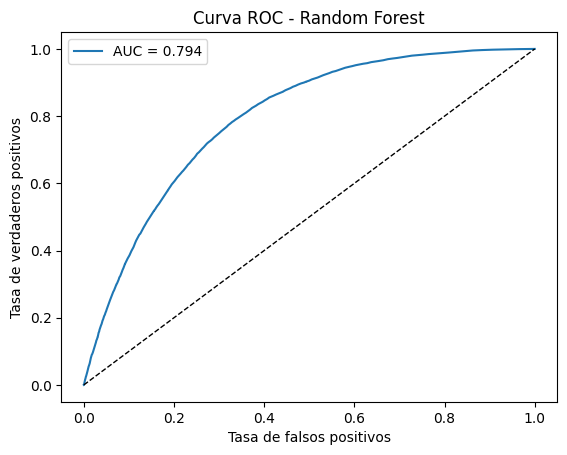

In [8]:
resultados_finales.append(evaluar_modelo("Random Forest", "modelo_rf.pkl", X_test, y_test, X_train, y_train))


## **Modelo de ``XGBClassifier``**


🔹 Modelo: XGBoost
AUC: 0.808 | F1: 0.308 | Recall: 0.230 | Accuracy: 0.858 | Train Score: 0.9284372664786154 | Test Score: 0.85807002330497 | Train Time: 5.38 s

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     63661
           1       0.47      0.23      0.31     10143

    accuracy                           0.86     73804
   macro avg       0.68      0.59      0.61     73804
weighted avg       0.83      0.86      0.84     73804



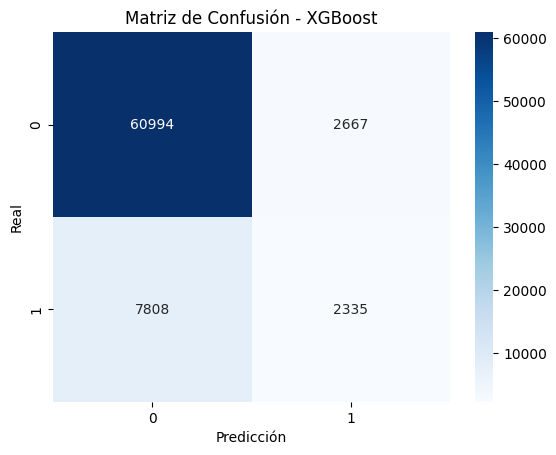

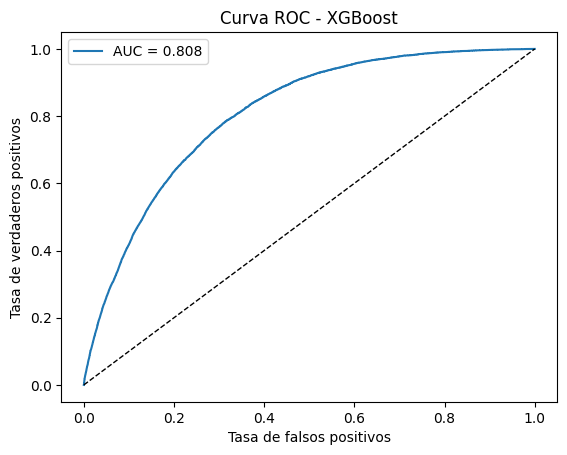

In [9]:
resultados_finales.append(evaluar_modelo("XGBoost", "modelo_xgb.pkl", X_test, y_test, X_train, y_train))

## **Modelo de ``LinearSVC``**


🔹 Modelo: Linear SVC
AUC: 0.789 | F1: 0.411 | Recall: 0.709 | Accuracy: 0.721 | Train Score: 0.7792764287301149 | Test Score: 0.7208145899951223 | Train Time: 8.97 s

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     63661
           1       0.29      0.71      0.41     10143

    accuracy                           0.72     73804
   macro avg       0.61      0.72      0.61     73804
weighted avg       0.85      0.72      0.76     73804



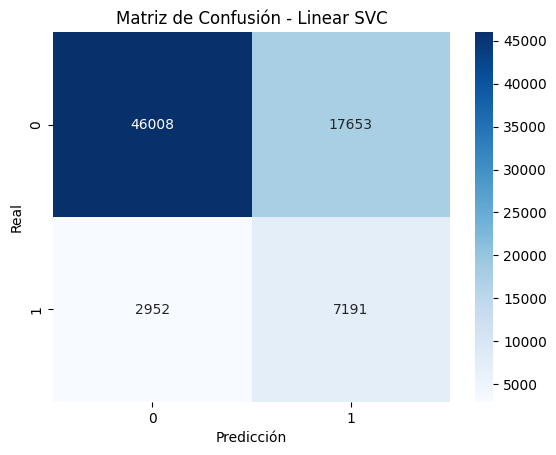

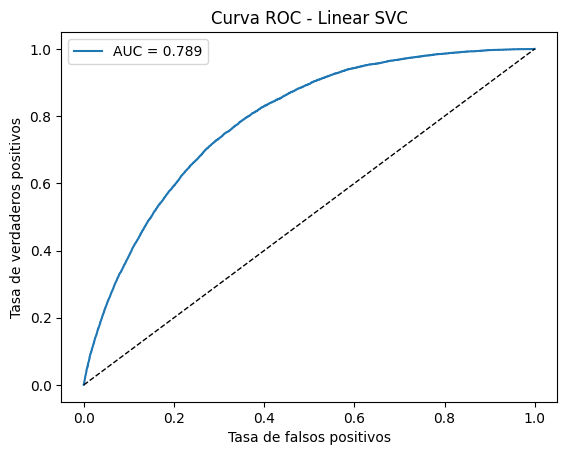

In [10]:
resultados_finales.append(evaluar_modelo("Linear SVC", "modelo_svm.pkl", X_test, y_test, X_train, y_train))

## **Modelo original ``HCSE``**


🔹 Modelo: HCSE model
AUC: 0.823 | F1: 0.437 | Recall: 0.760 | Accuracy: 0.731 | Train Score: 0.7488632998275352 | Test Score: 0.7309359926291258 | Train Time: 144.17 s

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.73      0.82     63661
           1       0.31      0.76      0.44     10143

    accuracy                           0.73     73804
   macro avg       0.63      0.74      0.63     73804
weighted avg       0.86      0.73      0.77     73804



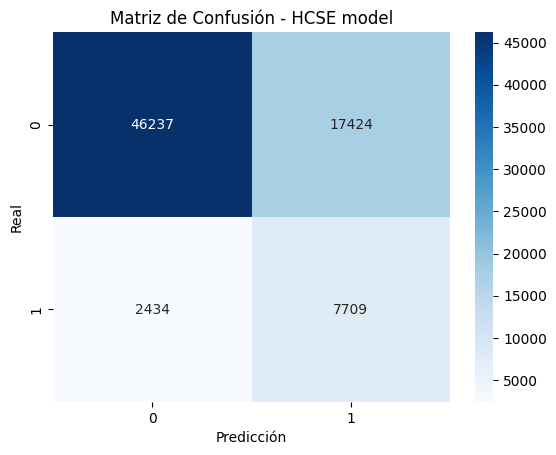

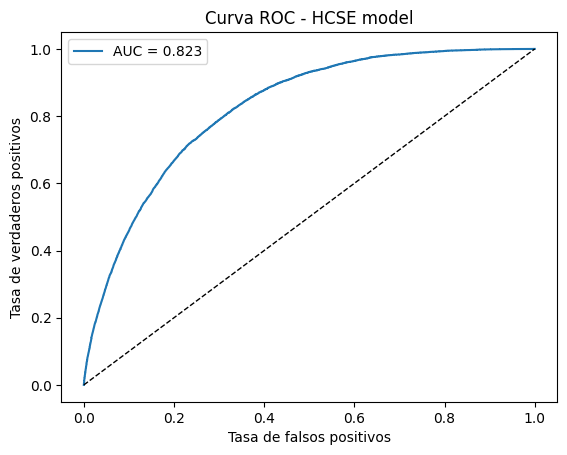

In [36]:
from hcse_model import HybridCostSensitiveEnsemble
X_train_ = pd.read_csv('X_train.csv')
X_test_ = pd.read_csv('X_test.csv')
y_train_ = pd.read_csv('y_train.csv')["diabetes"]
y_test_ = pd.read_csv('y_test.csv')["diabetes"]
resultados_finales.append(evaluar_modelo("HCSE model", "model_hcse.pkl", X_test_, y_test_, X_train_, y_train_))

## **Tabla Comparativa modelos validados**

In [ ]:
df_comparativa = (
    pd.DataFrame(resultados_finales)
      .sort_values(
          by=["AUC", "Recall"], 
          ascending=[ False, False]
      )
)
display(df_comparativa)


,Modelo,AUC,F1,Recall,Accuracy,Train Score,Test Score,Train Time (s)
2,Naive Bayes,0.738945,0.315209,0.833876,0.502060,0.692230,0.502060,1.795519
7,HCSE model,0.823403,0.437068,0.760032,0.730936,0.748863,0.730936,144.165682
6,Linear SVC,0.788576,0.411067,0.708962,0.720815,0.779276,0.720815,8.966398
0,Regresión Logística,0.788125,0.408844,0.708272,0.718511,0.780108,0.718511,6.292076
1,KNN,0.748408,0.374464,0.697131,0.679909,0.999690,0.679909,1.694877
3,Árbol de Decisión,0.751294,0.376830,0.630484,0.713417,0.779327,0.713417,4.286781
4,Random Forest,0.794302,0.380123,0.380854,0.829291,0.999690,0.829291,165.257268
5,XGBoost,0.807580,0.308353,0.230208,0.858070,0.928437,0.858070,5.383931


Las siguientes conclusiones se darán sin tener en cuenta el modelo original, en la siguiente seccion se hablará a fondo sobre este.

 **XGBoost** se posiciona como el **modelo con mejor desempeño global**, alcanzando el **mayor AUC (0.808)** y la **mayor exactitud (85.8%)**, además de un tiempo de entrenamiento razonable (7 s).  
  Su equilibrio entre precisión y capacidad de generalización lo convierte en la mejor opción para este conjunto de datos, aunque su *recall* (0.23) indica que tiende a ser conservador al detectar casos positivos.

- **Random Forest** obtuvo un AUC cercano (0.794) y un desempeño general robusto, pero con un **tiempo de entrenamiento considerablemente mayor (205 s)**.  
  Su *recall* moderado (0.38) y su alta precisión lo hacen ideal cuando se busca un modelo estable, aunque con alto costo computacional.

- **Linear SVC** y **Regresión Logística** presentaron resultados muy similares, con AUC ≈ 0.789 y *recall* ≈ 0.71, lo que evidencia su **alta sensibilidad hacia la clase positiva**.  
  Estos modelos lineales son más simples, rápidos y con buena capacidad de generalización, siendo ideales cuando se prioriza interpretabilidad y eficiencia.

- **Árbol de Decisión** alcanzó un rendimiento intermedio (AUC 0.75), mostrando un buen equilibrio entre sensibilidad (0.63) y precisión, aunque con menor estabilidad frente a otros métodos de ensamblado.

- **KNN** obtuvo un desempeño aceptable (AUC 0.75), con buen *recall* (0.70), pero sufre de **sobreajuste (train_score ≈ 1)** y una caída en generalización, lo que reduce su confiabilidad frente a nuevos datos.

- **Naive Bayes**, aunque logra el **mayor recall (0.83)** —detectando la mayoría de los casos positivos—, presenta **baja precisión y exactitud (0.50)**, lo que indica una alta tasa de falsos positivos.  
  No obstante, su **bajo tiempo de entrenamiento** lo hace útil como modelo base o de referencia rápida.


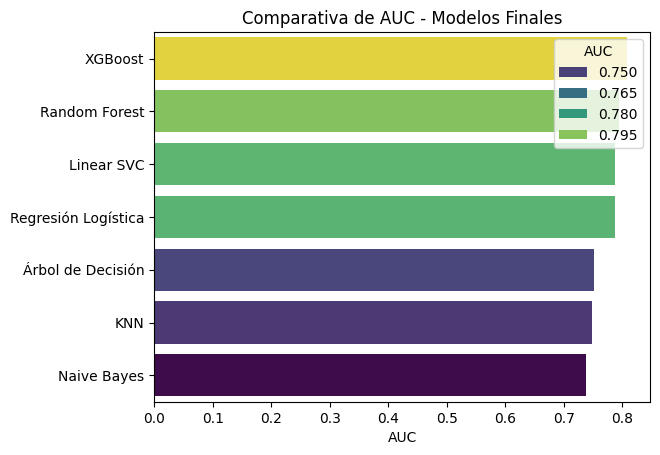

In [ ]:
sns.barplot(data=df_comparativa, x='AUC', y='Modelo', hue='AUC', palette='viridis')
plt.title("Comparativa de AUC - Modelos Finales")
plt.xlabel("AUC")
plt.ylabel("")
plt.show()



El análisis comparativo demuestra que los modelos basados en **árboles de ensamblado (XGBoost y Random Forest)** son los más eficaces para este conjunto de datos, destacando por su capacidad predictiva y estabilidad.  
Por su parte, los modelos **lineales (Linear SVC y Regresión Logística)** mantienen un excelente equilibrio entre desempeño y eficiencia, siendo adecuados para contextos donde la interpretabilidad y el costo computacional son factores clave.  
En cambio, **Naive Bayes** y **KNN** se destacan por su simplicidad y rapidez, pero su rendimiento es menor en términos de precisión y generalización.

### **Interpretación contextual del desempeño de los modelos**

En el contexto del estudio —la **predicción de diabetes**— el objetivo principal no es únicamente alcanzar la mayor precisión global, sino **detectar correctamente la mayor cantidad posible de pacientes con la enfermedad** (clase positiva).  
Por tanto, las métricas de mayor relevancia son el **Recall (Sensibilidad)** y, en segundo lugar, el **AUC**, que mide la capacidad general del modelo para distinguir entre personas con y sin diabetes.

Al analizar los resultados:

- **Linear SVC** y **Regresión Logística** obtuvieron los **mayores valores de Recall (≈0.71)**, lo que significa que detectan correctamente alrededor del **71 % de los casos positivos**.  
  Aunque su *accuracy* es menor que la de modelos más complejos, estos algoritmos lineales **maximizan la detección de pacientes con diabetes**, que es el objetivo prioritario en este tipo de problemas médicos.  
  Además, presentan una **alta interpretabilidad**, lo que permite identificar qué variables influyen más en el diagnóstico (por ejemplo, nivel de glucosa, presión sanguínea o índice de masa corporal).

- **XGBoost** y **Random Forest** alcanzaron **AUC y Accuracy más altos** (≈0.81 y 0.86, respectivamente), mostrando una excelente capacidad de discriminación y generalización.  
  Sin embargo, ambos tienden a **clasificar con mayor precisión los casos negativos**, sacrificando parte del *recall* (solo entre 0.23 y 0.38).  
  Esto puede implicar que **algunos pacientes con diabetes no sean correctamente detectados**, lo cual no es ideal en un contexto de salud pública donde los falsos negativos pueden tener consecuencias graves.

- **Naive Bayes**, aunque presenta baja precisión, logró el **mayor Recall (0.83)**, lo que significa que identifica la gran mayoría de los casos positivos, pero **con muchos falsos positivos**.  
  En un entorno clínico, este modelo podría ser útil como **modelo de cribado (screening)**, donde lo importante es no dejar pasar ningún caso sospechoso, aunque después se requiera una segunda validación con un modelo más específico.

En conjunto, se puede concluir que **los modelos lineales (Regresión Logística y Linear SVC)** representan la mejor alternativa para este tipo de estudio, ya que ofrecen un **buen balance entre sensibilidad, interpretabilidad y estabilidad**, mientras que **XGBoost** y **Random Forest** destacan cuando se busca **máxima precisión global y robustez en la clasificación**.



### **Conclusión general**
- Si el objetivo es **detectar el mayor número de pacientes con diabetes (minimizar falsos negativos)** → **Regresión Logística o Linear SVC** son las mejores opciones.  
- Si se busca **mayor exactitud global y robustez predictiva** → **XGBoost** es el modelo más fuerte.  
- Si se requiere **una herramienta rápida de detección preliminar** → **Naive Bayes** podría emplearse como filtro inicial.

En resumen, para el problema analizado, los resultados son **coherentes y adecuados**, ya que los modelos alcanzan niveles de desempeño esperables en datos médicos reales: **recall alto (~0.7–0.8), AUC sólido (~0.8) y generalización estable**, cumpliendo con los objetivos del proyecto.